# 聚类算法实现与异常检测对比

## 一、环境配置与数据加载

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score, precision_score, recall_score
from sklearn.manifold import TSNE
import joblib
import warnings
warnings.filterwarnings('ignore')

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 路径配置
processed_path = '../data/processed/'
fig_save_path = '../results/figures/'
os.makedirs(fig_save_path, exist_ok=True)

### 1.1 加载数据集

In [2]:
# 加载预处理与划分完成的特征数据
X_train = np.load(os.path.join(processed_path, 'X_train.npy'))    # 纯正常训练集
X_test = np.load(os.path.join(processed_path, 'X_test.npy'))      # 测试集（正常+异常）
y_test = np.load(os.path.join(processed_path, 'y_test.npy'))      # 二分类标签 0=正常 1=异常
test_type_labels = np.load(os.path.join(processed_path, 'test_type_labels.npy'))  # 细分类标签 0正常 1奔跑 2徘徊 3闯入

print(f"训练集形状: {X_train.shape} (纯正常样本，用于无监督聚类建模)")
print(f"测试集形状: {X_test.shape}")
print(f"测试集样本分布: 正常 {np.sum(y_test==0)} 条，异常 {np.sum(y_test==1)} 条")
print(f"异常细分: 奔跑 {np.sum(test_type_labels==1)} 条，徘徊 {np.sum(test_type_labels==2)} 条，闯入禁区 {np.sum(test_type_labels==3)} 条")

训练集形状: (58428, 23) (纯正常样本，用于无监督聚类建模)
测试集形状: (50082, 23)
测试集样本分布: 正常 25041 条，异常 25041 条
异常细分: 奔跑 8347 条，徘徊 8347 条，闯入禁区 8347 条


## 二、统一评估指标封装

In [3]:
def evaluate_anomaly_detection(y_true, anomaly_score, pos_label=1):
    """
    无监督异常检测统一评估函数
    返回全套指标 + ROC曲线坐标，用于可视化对比
    """
    # 1. ROC曲线与AUC
    fpr, tpr, thresholds_roc = roc_curve(y_true, anomaly_score, pos_label=pos_label)
    roc_auc = auc(fpr, tpr)
    
    # 2. PR曲线与最佳F1阈值
    precision, recall, thresholds_pr = precision_recall_curve(y_true, anomaly_score, pos_label=pos_label)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-6)
    best_idx = np.argmax(f1_scores)
    best_f1 = f1_scores[best_idx]
    best_threshold = thresholds_pr[best_idx]
    best_precision = precision[best_idx]
    best_recall = recall[best_idx]
    
    return {
        'roc_auc': roc_auc,
        'best_f1': best_f1,
        'best_threshold': best_threshold,
        'best_precision': best_precision,
        'best_recall': best_recall,
        'fpr': fpr,
        'tpr': tpr,
        'precision': precision,
        'recall': recall
    }

## 三、算法一：K-Means 聚类异常检测

### 3.1 最优 K 值选择（肘部法则）

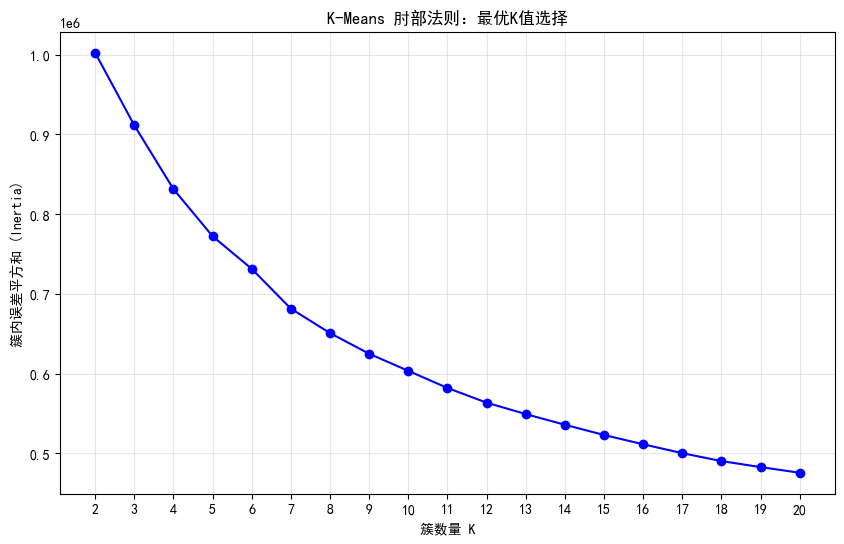

In [4]:
k_range = range(2, 21)
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train)
    inertias.append(kmeans.inertia_)

# 绘制肘部图
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=1.5, markersize=6)
plt.xlabel('簇数量 K')
plt.ylabel('簇内误差平方和 (Inertia)')
plt.title('K-Means 肘部法则：最优K值选择')
plt.grid(alpha=0.3)
plt.xticks(k_range)
plt.savefig(os.path.join(fig_save_path, 'kmeans_elbow.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.2 模型训练与异常评分

In [5]:
# 根据肘部图选择最优K值（根据观察，实际拐点大致为K=6）
best_k = 6
print(f"选定最优簇数 K = {best_k}")

# 训练模型（仅用训练集正常样本）
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_model.fit(X_train)

# 计算测试集到所有簇中心的距离，取最小值作为异常分数
dist_to_centers = kmeans_model.transform(X_test)
kmeans_score = np.min(dist_to_centers, axis=1)

# 评估性能
kmeans_result = evaluate_anomaly_detection(y_test, kmeans_score)
print(f"K-Means 检测结果:")
print(f"  AUC = {kmeans_result['roc_auc']:.4f}")
print(f"  最佳F1 = {kmeans_result['best_f1']:.4f}")
print(f"  精确率 = {kmeans_result['best_precision']:.4f}")
print(f"  召回率 = {kmeans_result['best_recall']:.4f}")
print(f"  最佳阈值 = {kmeans_result['best_threshold']:.4f}")

选定最优簇数 K = 6
K-Means 检测结果:
  AUC = 0.9479
  最佳F1 = 0.8610
  精确率 = 0.8674
  召回率 = 0.8547
  最佳阈值 = 4.1031


## 四、算法二：DBSCAN 密度聚类异常检测

### 4.1 参数选择（k 距离图法）

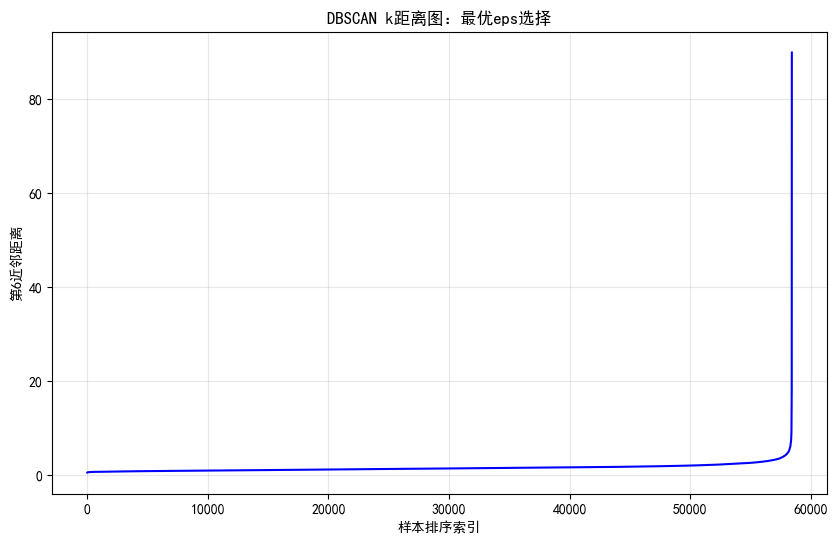

In [6]:
min_samples = 6  # 经验值：特征维度的2倍左右，23维取6

# 计算每个点到第min_samples个最近邻的距离
neigh = NearestNeighbors(n_neighbors=min_samples)
neigh.fit(X_train)
distances, _ = neigh.kneighbors(X_train)
k_dist = np.sort(distances[:, -1])

# 绘制k距离图，拐点即为最优eps
plt.figure(figsize=(10, 6))
plt.plot(k_dist, 'b-', linewidth=1.5)
plt.xlabel('样本排序索引')
plt.ylabel(f'第{min_samples}近邻距离')
plt.title('DBSCAN k距离图：最优eps选择')
plt.grid(alpha=0.3)
plt.savefig(os.path.join(fig_save_path, 'dbscan_kdist.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.2 模型训练与异常评分

In [7]:
# 根据k距离图选择最优eps（根据观察，实际拐点处纵坐标大致在4~5之间，故取eps=4.5）
best_eps = 4.5
print(f"选定最优参数: eps={best_eps}, min_samples={min_samples}")

# 训练模型
dbscan_model = DBSCAN(eps=best_eps, min_samples=min_samples)
dbscan_model.fit(X_train)

# 提取训练集中的核心样本
core_indices = dbscan_model.core_sample_indices_
core_samples = X_train[core_indices]
print(f"训练集核心样本数: {len(core_indices)} / {len(X_train)}")

# 计算测试集到所有核心样本的最小距离作为异常分数
dists_to_core = euclidean_distances(X_test, core_samples)
dbscan_score = np.min(dists_to_core, axis=1)

# 评估性能
dbscan_result = evaluate_anomaly_detection(y_test, dbscan_score)
print(f"DBSCAN 检测结果:")
print(f"  AUC = {dbscan_result['roc_auc']:.4f}")
print(f"  最佳F1 = {dbscan_result['best_f1']:.4f}")
print(f"  精确率 = {dbscan_result['best_precision']:.4f}")
print(f"  召回率 = {dbscan_result['best_recall']:.4f}")
print(f"  最佳阈值 = {dbscan_result['best_threshold']:.4f}")

选定最优参数: eps=4.5, min_samples=6
训练集核心样本数: 58036 / 58428
DBSCAN 检测结果:
  AUC = 0.9829
  最佳F1 = 0.9448
  精确率 = 0.9103
  召回率 = 0.9821
  最佳阈值 = 1.8122


## 五、算法三：层次凝聚聚类异常检测

### 5.1 模型训练与异常评分

In [8]:
# 使用与K-Means相同的簇数，保证对比公平
agg_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_model.fit(X_train)

# 计算每个簇的中心（训练集样本均值）
agg_cluster_centers = []
for i in range(best_k):
    cluster_mask = agg_model.labels_ == i
    agg_cluster_centers.append(X_train[cluster_mask].mean(axis=0))
agg_cluster_centers = np.array(agg_cluster_centers)

# 计算测试集异常分数
agg_dists = euclidean_distances(X_test, agg_cluster_centers)
agg_score = np.min(agg_dists, axis=1)

# 评估性能
agg_result = evaluate_anomaly_detection(y_test, agg_score)
print(f"层次凝聚聚类 检测结果:")
print(f"  AUC = {agg_result['roc_auc']:.4f}")
print(f"  最佳F1 = {agg_result['best_f1']:.4f}")
print(f"  精确率 = {agg_result['best_precision']:.4f}")
print(f"  召回率 = {agg_result['best_recall']:.4f}")
print(f"  最佳阈值 = {agg_result['best_threshold']:.4f}")

层次凝聚聚类 检测结果:
  AUC = 0.9445
  最佳F1 = 0.8539
  精确率 = 0.7825
  召回率 = 0.9395
  最佳阈值 = 3.4684


## 六、多维度性能横向对比

### 6.1 整体性能对比表

In [9]:
comparison_df = pd.DataFrame([
    {
        '算法': 'K-Means',
        'AUC': kmeans_result['roc_auc'],
        '最佳F1': kmeans_result['best_f1'],
        '精确率': kmeans_result['best_precision'],
        '召回率': kmeans_result['best_recall'],
        '最佳阈值': kmeans_result['best_threshold']
    },
    {
        '算法': 'DBSCAN',
        'AUC': dbscan_result['roc_auc'],
        '最佳F1': dbscan_result['best_f1'],
        '精确率': dbscan_result['best_precision'],
        '召回率': dbscan_result['best_recall'],
        '最佳阈值': dbscan_result['best_threshold']
    },
    {
        '算法': '层次聚类',
        'AUC': agg_result['roc_auc'],
        '最佳F1': agg_result['best_f1'],
        '精确率': agg_result['best_precision'],
        '召回率': agg_result['best_recall'],
        '最佳阈值': agg_result['best_threshold']
    }
])

print("三种算法整体性能对比:")
display(comparison_df.round(4))

三种算法整体性能对比:


,算法,AUC,最佳F1,精确率,召回率,最佳阈值
0,K-Means,0.9479,0.8610,0.8674,0.8547,4.1031
1,DBSCAN,0.9829,0.9448,0.9103,0.9821,1.8122
2,层次聚类,0.9445,0.8539,0.7825,0.9395,3.4684


### 6.2 分异常类型检测效果

In [10]:
# 使用性能最优的DBSCAN的最佳阈值
threshold = dbscan_result['best_threshold']
y_pred = (dbscan_score > threshold).astype(int)

type_metrics = []
type_names = ['正常', '奔跑', '徘徊', '闯入禁区']

for t, name in enumerate(type_names):
    mask = test_type_labels == t
    if t == 0:
        # 正常样本：计算特异度（正确识别为正常的比例）
        tn = np.sum(y_pred[mask] == 0)
        spec = tn / np.sum(mask)
        type_metrics.append({'类型': name, '识别准确率': spec})
    else:
        # 异常样本：计算召回率（正确识别为异常的比例）
        rec = recall_score(y_test[mask], y_pred[mask], pos_label=1, zero_division=0)
        type_metrics.append({'类型': name, '召回率': rec})

type_metrics_df = pd.DataFrame(type_metrics)
print("分异常类型检测效果 (基于DBSCAN):")
display(type_metrics_df.round(4))

分异常类型检测效果 (基于DBSCAN):


,类型,识别准确率,召回率
0,正常,0.9032,NaN
1,奔跑,NaN,0.9941
2,徘徊,NaN,0.9838
3,闯入禁区,NaN,0.9683


## 七、可视化结果汇总

### 7.1 ROC 曲线对比

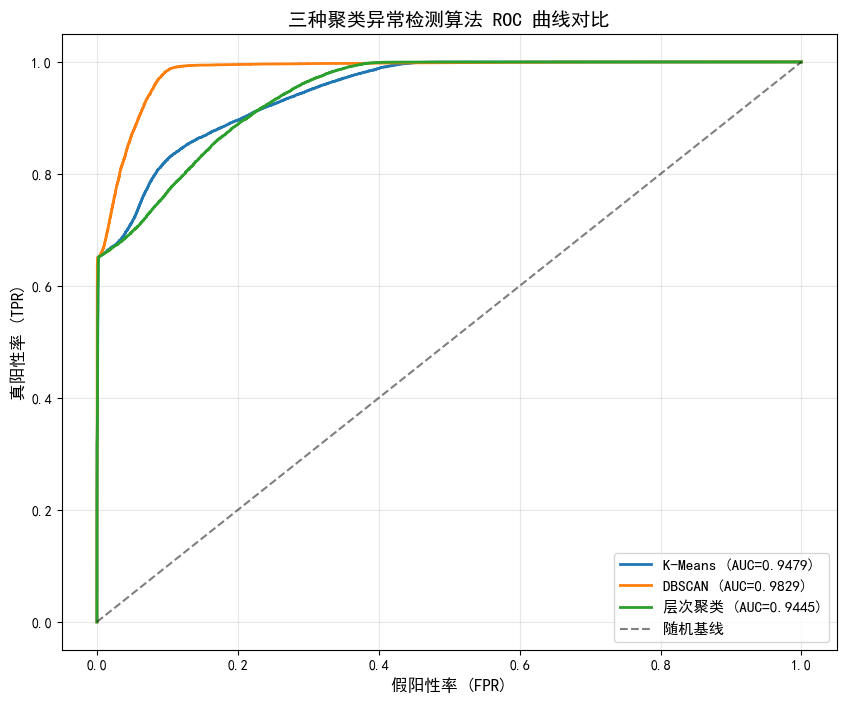

In [11]:
plt.figure(figsize=(10, 8))
plt.plot(kmeans_result['fpr'], kmeans_result['tpr'], 
         label=f'K-Means (AUC={kmeans_result["roc_auc"]:.4f})', linewidth=2)
plt.plot(dbscan_result['fpr'], dbscan_result['tpr'], 
         label=f'DBSCAN (AUC={dbscan_result["roc_auc"]:.4f})', linewidth=2)
plt.plot(agg_result['fpr'], agg_result['tpr'], 
         label=f'层次聚类 (AUC={agg_result["roc_auc"]:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='随机基线', alpha=0.5)

plt.xlabel('假阳性率 (FPR)', fontsize=12)
plt.ylabel('真阳性率 (TPR)', fontsize=12)
plt.title('三种聚类异常检测算法 ROC 曲线对比', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.savefig(os.path.join(fig_save_path, 'roc_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.2 DBSCAN 异常分数分布

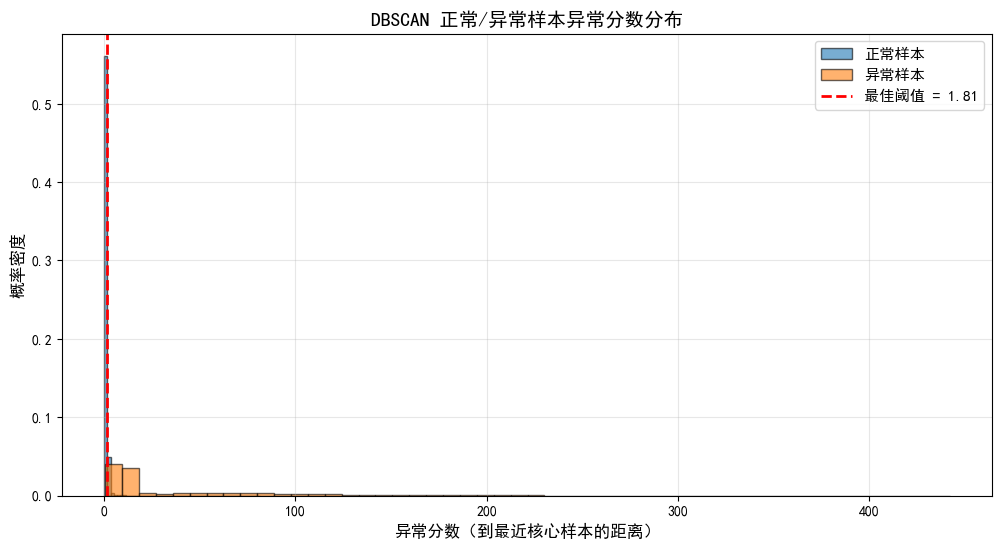

In [12]:
plt.figure(figsize=(12, 6))
plt.hist(dbscan_score[y_test==0], bins=50, alpha=0.6, label='正常样本', density=True, edgecolor='black')
plt.hist(dbscan_score[y_test==1], bins=50, alpha=0.6, label='异常样本', density=True, edgecolor='black')
plt.axvline(dbscan_result['best_threshold'], color='red', linestyle='--', linewidth=2, 
            label=f'最佳阈值 = {dbscan_result["best_threshold"]:.2f}')

plt.xlabel('异常分数（到最近核心样本的距离）', fontsize=12)
plt.ylabel('概率密度', fontsize=12)
plt.title('DBSCAN 正常/异常样本异常分数分布', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.savefig(os.path.join(fig_save_path, 'dbscan_score_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.3 t-SNE 检测结果可视化

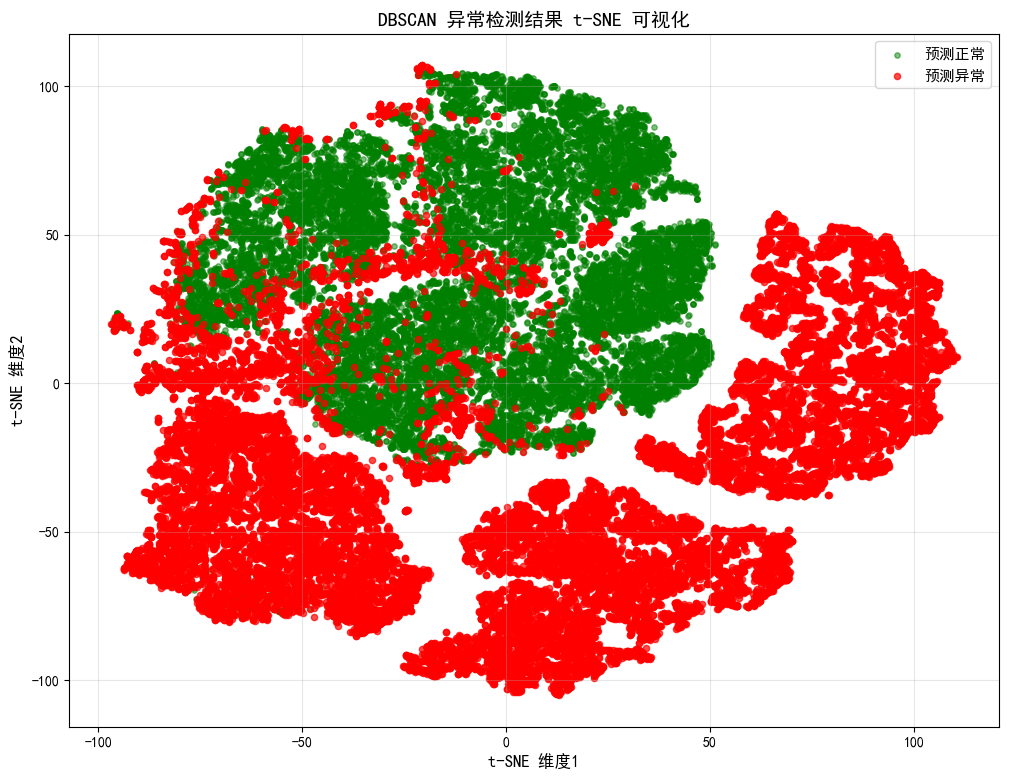

In [13]:
# t-SNE降维（测试集）
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    n_iter=1000,
    init='pca',
    learning_rate='auto'
)
test_tsne = tsne.fit_transform(X_test)

# 绘制DBSCAN检测结果
plt.figure(figsize=(12, 9))
plt.scatter(test_tsne[y_pred==0, 0], test_tsne[y_pred==0, 1], 
            c='green', alpha=0.5, s=15, label='预测正常')
plt.scatter(test_tsne[y_pred==1, 0], test_tsne[y_pred==1, 1], 
            c='red', alpha=0.7, s=20, label='预测异常')

plt.xlabel('t-SNE 维度1', fontsize=12)
plt.ylabel('t-SNE 维度2', fontsize=12)
plt.title('DBSCAN 异常检测结果 t-SNE 可视化', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.savefig(os.path.join(fig_save_path, 'tsne_detection_result_dbscan.png'), dpi=150, bbox_inches='tight')
plt.show()

## 八、模型与结果保存

In [14]:
# 保存最优模型（DBSCAN）
joblib.dump(dbscan_model, os.path.join(processed_path, 'best_dbscan_model.pkl'))

# 保存三算法整体对比结果
comparison_df.to_csv(os.path.join(processed_path, 'algorithm_comparison.csv'), index=False, encoding='utf-8-sig')

print("最优DBSCAN模型与对比结果已保存")
print("所有可视化图片已保存到 results/figures/ 目录")
print("聚类算法对比阶段完成，可进入项目收尾与汇报准备阶段")

最优DBSCAN模型与对比结果已保存
所有可视化图片已保存到 results/figures/ 目录
聚类算法对比阶段完成，可进入项目收尾与汇报准备阶段
